<a href="https://colab.research.google.com/github/xxcorn888-cyber/solubility-prediction/blob/main/solubility_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 37.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df=pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv")
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df["MolWt"] = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["TPSA"] = df["mol"].apply(Descriptors.TPSA)
df[["smiles","MolWt","LogP","TPSA"]].head()

,smiles,MolWt,LogP,TPSA
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,457.432,-3.10802,202.32
1,Cc1occc1C(=O)Nc2ccccc2,201.225,2.84032,42.24
2,CC(C)=CCCC(C)=CC(=O),152.237,2.87800,17.07
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,278.354,6.29940,0.00
4,c1ccsc1,84.143,1.74810,0.00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X = df[["MolWt","LogP","TPSA"]]
y = df["measured log solubility in mols per litre"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.848094459503942

In [ ]:
df["HBD"] = df["mol"].apply(Descriptors.NumHDonors)
df["HBA"] = df["mol"].apply(Descriptors.NumHAcceptors)
df["RotB"] = df["mol"].apply(Descriptors.NumRotatableBonds)
df["AromRings"] = df["mol"].apply(Descriptors.NumAromaticRings)
X = df[["MolWt","LogP","TPSA","HBD","HBA","RotB","AromRings"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8595120064152477

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

,0
LogP,0.816465
MolWt,0.103064
TPSA,0.042071
RotB,0.011921
HBA,0.010552
AromRings,0.009062
HBD,0.006865


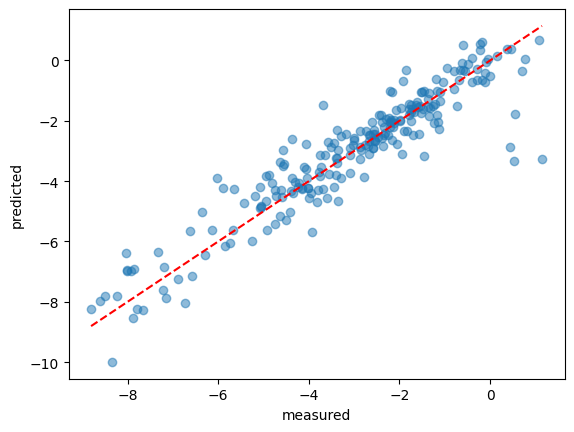

In [ ]:
import matplotlib.pyplot as plt
pred = model.predict(X_test)
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("measured")
plt.ylabel("predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()